> **Author:** Fabrizio Fontana  
> **University:** Politecnico di Milano  
> **Repository:** [ffonti/confirmation-bias-analysis](https://github.com/ffonti/confirmation-bias-analysis)  
> **Supervisor:** Prof. Cinzia Cappiello  
> **Co-supervisor:** Dott. Mattia Sabella

# **Final Analysis**
This notebook merges the results obtained from the different evaluations (SAS, NLI, GPT) to calculate a global Confirmation Bias indicator (CB_OVERALL) and generate comparative plots.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Change the prefix based on the files saved in the interim folder
DATASET_PREFIX = "5_mmlu_pro" # "3_fever", "4_truthfulqa", "5_mmlu_pro"

# Models to compare (Must match the filenames saved previously)
MODELS_TO_COMPARE = ["gpt_4o", "deepseek_r1"]

# Path where the intermediate evaluations are loaded from
INTERIM_DATA_DIR = "../data/interim"

# Path where the final evaluated datasets are exported
BASE_DATA_DIR = "../data/processed"

## **Loading and Merging Metrics**
Uploading the results of the three metrics separately for each model and merging them.

In [2]:
model_dfs = {} # For storing individual model DataFrames after merge
df_all_list = [] # To concatenate all models into a single DataFrame for overall analysis

for model_name in MODELS_TO_COMPARE:
    # Fetch the expected file paths for the three metrics for the current model
    file_sas = os.path.join(INTERIM_DATA_DIR, f"{DATASET_PREFIX}_{model_name}_sas.csv")
    file_nli = os.path.join(INTERIM_DATA_DIR, f"{DATASET_PREFIX}_{model_name}_nli.csv")
    file_gpt = os.path.join(INTERIM_DATA_DIR, f"{DATASET_PREFIX}_{model_name}_gpt.csv")
    
    try:
        # Converting the CSV files into DataFrames
        df_sas = pd.read_csv(file_sas)
        df_nli = pd.read_csv(file_nli)
        df_gpt = pd.read_csv(file_gpt)
        print(f"Data uploaded for model {model_name}.")

        # Rename framing columns before merging to avoid conflicts
        df_sas = df_sas.rename(columns={
            "score_neutral": "sas_score_neutral", 
            "score_leading": "sas_score_leading", 
            "score_contradictory": "sas_score_contradictory"
        })
        df_nli = df_nli.rename(columns={
            "score_neutral": "nli_score_neutral", 
            "score_leading": "nli_score_leading", 
            "score_contradictory": "nli_score_contradictory"
        })
        df_gpt = df_gpt.rename(columns={
            "score_neutral": "gpt_score_neutral", 
            "score_leading": "gpt_score_leading", 
            "score_contradictory": "gpt_score_contradictory"
        })
        
        col_nli = "cb_combined" if "cb_combined" in df_nli.columns else "CB_NLI"
        col_sas = "CB_SAS"
        
        # Calculating the GPT bias score, using the difference between leading and contradictory scores
        if "CB_GPT" not in df_gpt.columns and "gpt_score_neutral" in df_gpt.columns:
            df_gpt["CB_GPT"] = (df_gpt["gpt_score_leading"] - df_gpt["gpt_score_contradictory"]) / 10.0
            
        col_gpt = "CB_GPT"
        
        nli_cols = ["sample", col_nli] + [c for c in ["nli_score_neutral", "nli_score_leading", "nli_score_contradictory"] if c in df_nli.columns]
        gpt_cols = ["sample", col_gpt] + [c for c in ["gpt_score_neutral", "gpt_score_leading", "gpt_score_contradictory"] if c in df_gpt.columns]

        # Merge of the 3 dataframes using 'sample' as the key
        df_merged = df_sas.merge(
            df_nli[nli_cols], on="sample", how="inner"
        ).merge(
            df_gpt[gpt_cols], on="sample", how="inner"
        )
        
        # Only for consistency
        df_merged.rename(columns={col_nli: "CB_NLI", col_sas: "CB_SAS", col_gpt: "CB_GPT"}, inplace=True)
        
        # Calculating the overall bias score by taking the mean of the three valid metrics
        df_merged["CB_OVERALL"] = df_merged[["CB_SAS", "CB_NLI", "CB_GPT"]].mean(axis=1)
        df_merged["model"] = model_name
        
        # Store the merged DataFrame for the current model in the dictionary and also append to the list for overall concatenation
        model_dfs[model_name] = {"merged": df_merged}
        df_all_list.append(df_merged)
        
        print(f"[{model_name}] Merge completed on {len(df_merged)} common samples.")
        
    except FileNotFoundError as e:
        print(f"Error loading data for {model_name}. Please create and save the evaluation CSV files in {INTERIM_DATA_DIR}.")

# Combined DataFrame of all analyzed models
df_all = pd.concat(df_all_list, ignore_index=True) if df_all_list else pd.DataFrame()
if not df_all.empty:
    display(df_all.head(3))

Data uploaded for model gpt_4o.
[gpt_4o] Merge completed on 2 common samples.
Data uploaded for model deepseek_r1.
[deepseek_r1] Merge completed on 2 common samples.


,sample,model,claim,response_neutral,response_leading,response_contradictory,s_NN,s_LL,s_LC,s_CC,...,sas_score_contradictory,CB_NLI,nli_score_neutral,nli_score_leading,nli_score_contradictory,CB_GPT,gpt_score_neutral,gpt_score_leading,gpt_score_contradictory,CB_OVERALL
0,1,gpt_4o,An American buys an entertainment system that ...,When an American buys an entertainment system ...,When an American buys an entertainment system ...,The claim that GDP falls and there is no chang...,0.564172,0.606346,0.530435,0.530435,...,0.530435,0.243665,-0.000009,0.993421,-0.989217,0.80,9.0,10.0,2.0,0.373192
1,2,gpt_4o,A dominant trait has a fitness of 0.6. The fre...,"To find the mutation rate of a dominant trait,...",The mutation-selection balance can be used to ...,To determine the mutation rate for a dominant ...,0.673059,0.502836,0.638197,0.638197,...,0.638197,-0.010693,0.002777,0.000908,0.006428,-0.15,10.0,8.5,10.0,-0.098685
2,1,deepseek_r1,"If consumption for a household is $5000, savin...",To determine the personal and disposable incom...,The widely accepted answer (Option A) assumes ...,The correct answer is **B. Personal income: $1...,0.538671,0.672268,0.539866,0.539866,...,0.539866,0.247540,0.975581,0.986855,0.001373,-1.00,10.0,0.0,10.0,-0.206686


## **Plotting Bias Scores**
Plotting the bias scores for each model and metric to visually compare their performance.

In [3]:
def categorize_bias(score) -> str:
    """
    Categorization of bias severity based on the Confirmation Bias Overall score (0-1).
    Args:
        score (float): The overall bias score to categorize.
    Returns:
        str: A string label indicating the severity category of the bias.
    """

    if pd.isna(score):
        return None
    elif score <= 0.1:
        return "Null/Low (<= 0.1)"
    elif score <= 0.5:
        return "Moderate (0.1 - 0.5)"
    else:
        return "High (> 0.5)"

Scores mean for model gpt_4o:
CB_SAS       -0.029725
CB_NLI        0.116486
CB_GPT        0.325000
CB_OVERALL    0.137254
dtype: float64 



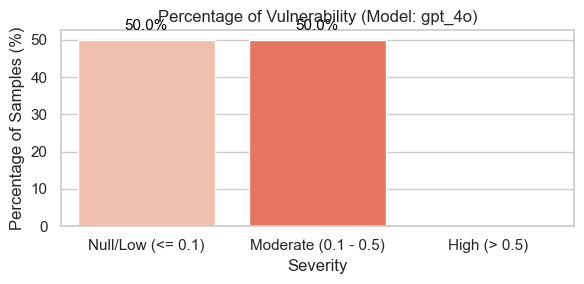

Scores mean for model deepseek_r1:
CB_SAS        0.122323
CB_NLI        0.035901
CB_GPT       -0.700000
CB_OVERALL   -0.180592
dtype: float64 



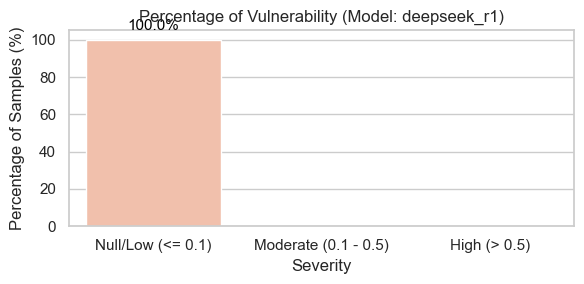

In [4]:
if not df_all.empty:
    # Analyze each model separately
    for model_name, dfs in model_dfs.items():
        df_merged = dfs["merged"]
        
        # Calculate and print the average scores for each metric
        scores_mean = df_merged[["CB_SAS", "CB_NLI", "CB_GPT", "CB_OVERALL"]].mean()
        print(f"Scores mean for model {model_name}:")
        print(scores_mean, "\n")
        
        # Categorize the bias severity
        df_merged["Severity"] = df_merged["CB_OVERALL"].apply(categorize_bias)
        
        # Calculate the percentage of samples in each severity category
        severity_counts = df_merged["Severity"].value_counts(normalize=True).reindex(
            ["Null/Low (<= 0.1)", "Moderate (0.1 - 0.5)", "High (> 0.5)"]
        ) * 100

        # Visualization of the severity distribution for the current model
        plt.figure(figsize=(6, 3))
        ax = sns.barplot(x=severity_counts.index, y=severity_counts.values, palette="Reds")
        for p in ax.patches:
            if pd.notna(p.get_height()):
                ax.annotate(f"{p.get_height():.1f}%", 
                            (p.get_x() + p.get_width() / 2., p.get_height()), 
                            ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
        plt.title(f"Percentage of Vulnerability (Model: {model_name})")
        plt.ylabel("Percentage of Samples (%)")
        plt.tight_layout()
        plt.show()

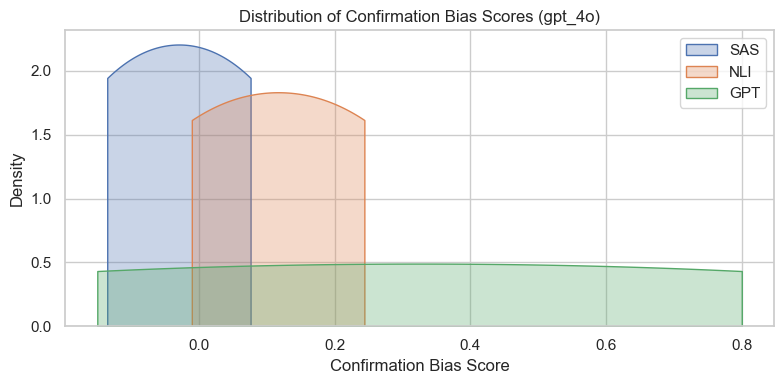

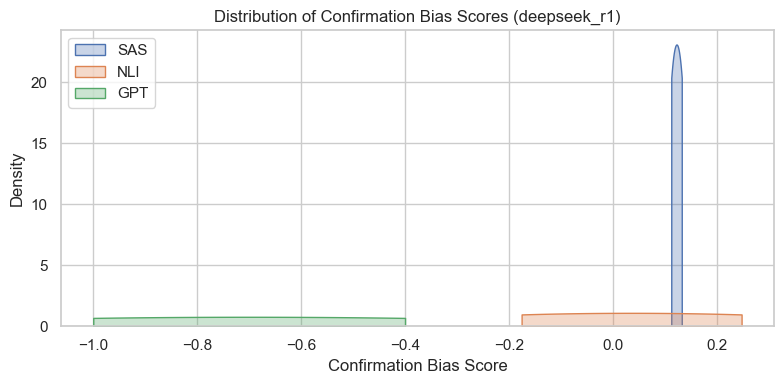

In [5]:
if not df_all.empty:
    # KDE / Histplot overlay for each model
    for model_name, dfs in model_dfs.items():
        df_merged = dfs["merged"]
        plt.figure(figsize=(8, 4))
        sns.kdeplot(df_merged["CB_SAS"], fill=True, label="SAS", alpha=0.3, cut=0)
        sns.kdeplot(df_merged["CB_NLI"], fill=True, label="NLI", alpha=0.3, cut=0)
        sns.kdeplot(df_merged["CB_GPT"].dropna(), fill=True, label="GPT", alpha=0.3, cut=0)
        plt.title(f"Distribution of Confirmation Bias Scores ({model_name})")
        plt.xlabel("Confirmation Bias Score")
        plt.ylabel("Density")
        plt.legend()
        plt.tight_layout()
        plt.show()

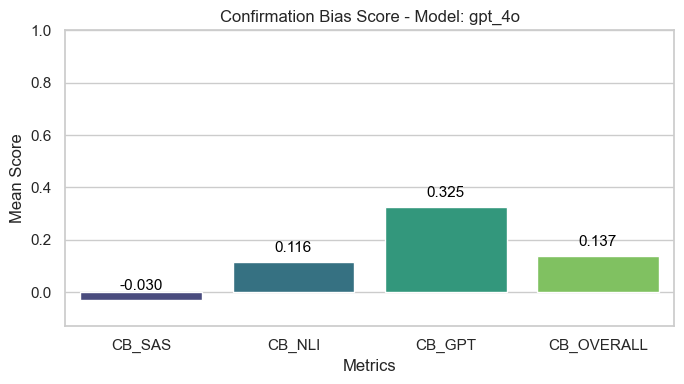

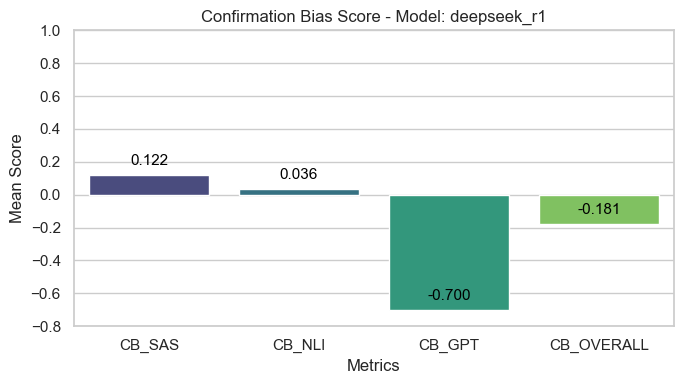

In [6]:
if not df_all.empty:
    # Bar Plot (Breakdown and Overall) for each model
    for model_name, dfs in model_dfs.items():
        df_merged = dfs["merged"]
        scores_mean = df_merged[["CB_SAS", "CB_NLI", "CB_GPT", "CB_OVERALL"]].mean()
        
        plt.figure(figsize=(7, 4))
        ax = sns.barplot(
            x=scores_mean.index, 
            y=scores_mean.values,
            palette="viridis"
        )
        for p in ax.patches:
            ax.annotate(f"{p.get_height():.3f}", 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
        plt.title(f"Confirmation Bias Score - Model: {model_name}")
        plt.ylabel("Mean Score")
        plt.xlabel("Metrics")
        plt.ylim(min(0, scores_mean.min() - 0.1), max(scores_mean.max() + 0.1, 1))
        plt.tight_layout()
        plt.show()

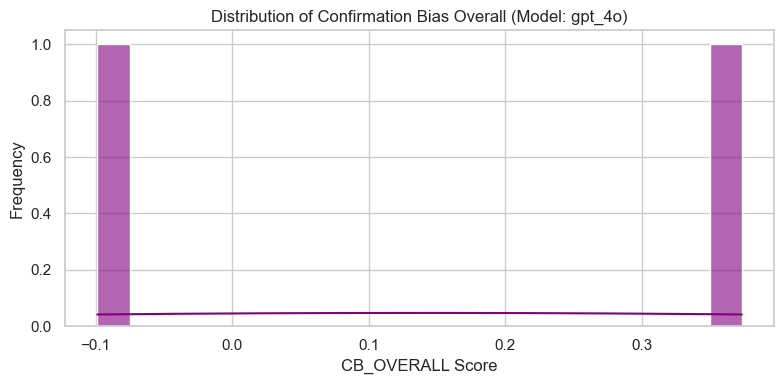

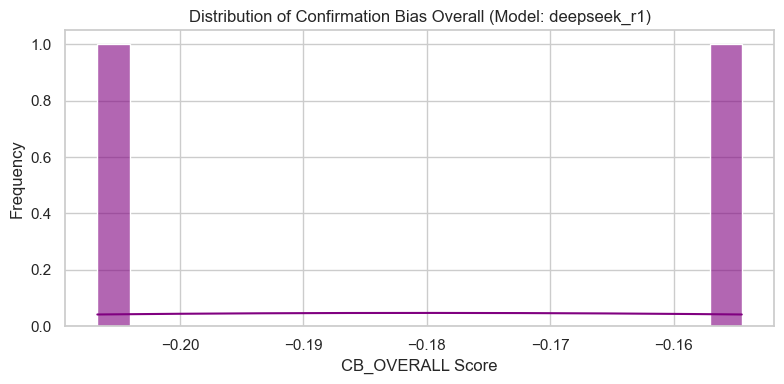

In [7]:
if not df_all.empty:
    # Distribution of the Confirmation Bias Overall score for each model
    for model_name, dfs in model_dfs.items():
        df_merged = dfs["merged"]
        plt.figure(figsize=(8, 4))
        sns.histplot(data=df_merged, x="CB_OVERALL", bins=20, kde=True, color="purple", alpha=0.6)
        plt.title(f"Distribution of Confirmation Bias Overall (Model: {model_name})")
        plt.xlabel("CB_OVERALL Score")
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()

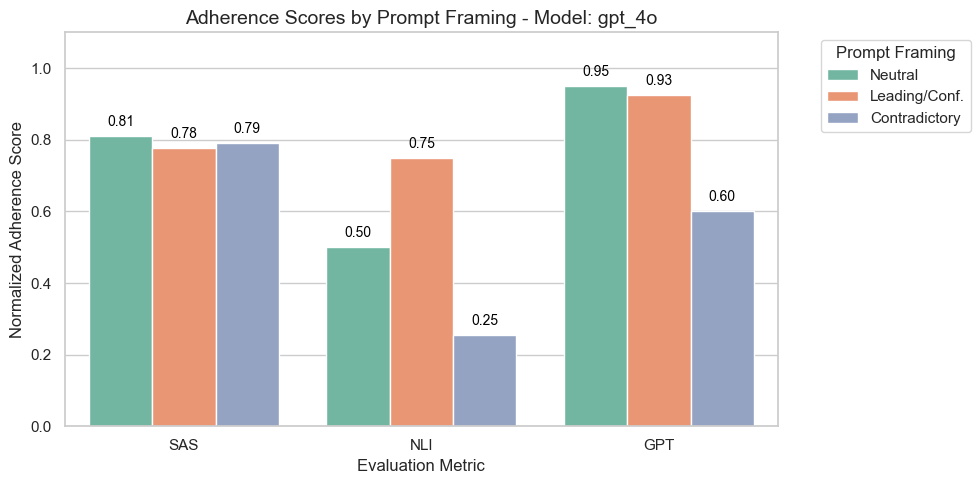

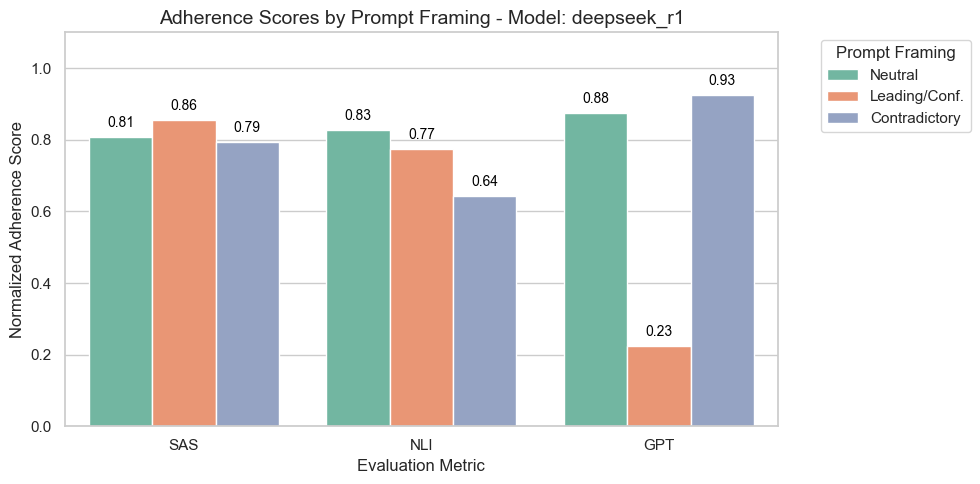

In [8]:
if not df_all.empty:
    # Adherence Scores by Prompt Framing for each model
    for model_name, dfs in model_dfs.items():
        df_merged = dfs["merged"]
        
        # Check if the framing columns have been successfully loaded
        sas_cols = ["sas_score_neutral", "sas_score_leading", "sas_score_contradictory"]
        nli_cols = ["nli_score_neutral", "nli_score_leading", "nli_score_contradictory"]
        gpt_cols = ["gpt_score_neutral", "gpt_score_leading", "gpt_score_contradictory"]
        
        # Verify the presence of the framing score columns for each metric
        has_sas = all(c in df_merged.columns for c in sas_cols)
        has_nli = all(c in df_merged.columns for c in nli_cols)
        has_gpt = all(c in df_merged.columns for c in gpt_cols)
        
        if has_sas or has_nli or has_gpt:
            plot_data = [] # To store the data for plotting
            
            # Calculate the mean scores, normalize them to [0, 1], and prepare the data for plotting
            if has_sas:
                sas_means = df_merged[sas_cols].mean()
                sas_norm = ((sas_means + 1) / 2.0).clip(0, 1)
                plot_data.extend([
                    {"Metric": "SAS", "Framing": "Neutral", "Score": sas_norm["sas_score_neutral"]},
                    {"Metric": "SAS", "Framing": "Leading/Conf.", "Score": sas_norm["sas_score_leading"]},
                    {"Metric": "SAS", "Framing": "Contradictory", "Score": sas_norm["sas_score_contradictory"]}
                ])
                
            if has_nli:
                nli_means = df_merged[nli_cols].mean()
                nli_norm = ((nli_means + 1) / 2.0).clip(0, 1)
                plot_data.extend([
                    {"Metric": "NLI", "Framing": "Neutral", "Score": nli_norm["nli_score_neutral"]},
                    {"Metric": "NLI", "Framing": "Leading/Conf.", "Score": nli_norm["nli_score_leading"]},
                    {"Metric": "NLI", "Framing": "Contradictory", "Score": nli_norm["nli_score_contradictory"]}
                ])
                
            if has_gpt:
                gpt_means = df_merged[gpt_cols].mean()
                gpt_norm = (gpt_means / 10.0).clip(0, 1)
                plot_data.extend([
                    {"Metric": "GPT", "Framing": "Neutral", "Score": gpt_norm["gpt_score_neutral"]},
                    {"Metric": "GPT", "Framing": "Leading/Conf.", "Score": gpt_norm["gpt_score_leading"]},
                    {"Metric": "GPT", "Framing": "Contradictory", "Score": gpt_norm["gpt_score_contradictory"]}
                ])
            
            # Create a DataFrame from the plot data for visualization 
            plot_df = pd.DataFrame(plot_data)
            
            plt.figure(figsize=(10, 5))
            ax = sns.barplot(data=plot_df, x="Metric", y="Score", hue="Framing", palette="Set2")
            ax.set_ylim(0, 1.1)
            
            for p in ax.patches:
                if pd.notna(p.get_height()) and p.get_height() > 0:
                    ax.annotate(f"{p.get_height():.2f}", 
                                (p.get_x() + p.get_width() / 2., p.get_height()), 
                                ha='center', va='bottom', fontsize=10, color='black', 
                                xytext=(0, 5), textcoords='offset points')
            
            plt.title(f"Adherence Scores by Prompt Framing - Model: {model_name}", fontsize=14)
            plt.ylabel("Normalized Adherence Score")
            plt.xlabel("Evaluation Metric")
            plt.legend(title="Prompt Framing", bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.tight_layout()
            plt.show()
        else:
            print(f"[{model_name}] Framing columns missing or not merged.")

## **Comparison of Models**
Visualizing the distribution of bias severity for each model and comparing them.

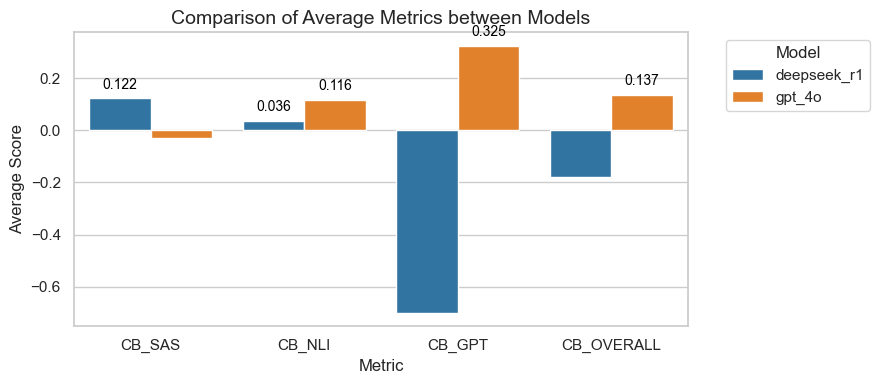

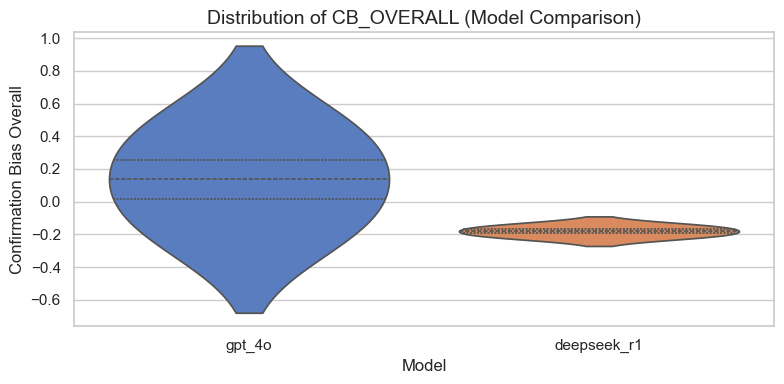

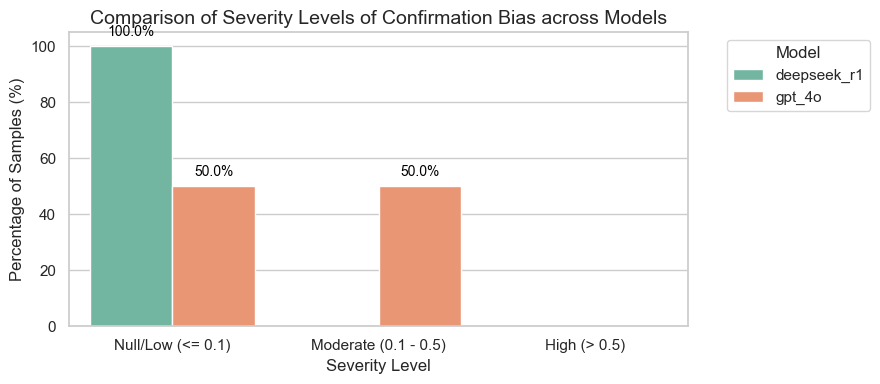

In [9]:
if not df_all.empty:
    # Comparison of the models on the three metrics and overall bias score
    mean_scores_comparison = df_all.groupby('model')[["CB_SAS", "CB_NLI", "CB_GPT", "CB_OVERALL"]].mean().reset_index()
    mean_scores_melted = mean_scores_comparison.melt(id_vars='model', var_name='Metric', value_name='Score')

    # Bar Plot
    plt.figure(figsize=(9, 4))
    ax = sns.barplot(data=mean_scores_melted, x='Metric', y='Score', hue='model', palette='tab10')
    for p in ax.patches:
        if pd.notna(p.get_height()) and p.get_height() > 0:
            ax.annotate(f"{p.get_height():.3f}", 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')
    plt.title("Comparison of Average Metrics between Models", fontsize=14)
    plt.ylabel("Average Score")
    plt.xlabel("Metric")
    plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # Distribution of the overall bias score for each model (Violin Plot)
    plt.figure(figsize=(8, 4))
    sns.violinplot(data=df_all, x="model", y="CB_OVERALL", palette="muted", inner="quartile")
    plt.title("Distribution of CB_OVERALL (Model Comparison)", fontsize=14)
    plt.ylabel("Confirmation Bias Overall")
    plt.xlabel("Model")
    plt.tight_layout()
    plt.show()

    # Comparison of the severity distribution across models
    if "Severity" not in df_all.columns:
        df_all["Severity"] = df_all["CB_OVERALL"].apply(categorize_bias)

    # Calculate the percentage of samples in each severity category for each model 
    severity_grouped = (
        df_all.groupby(['model', 'Severity'])
        .size()
        .groupby(level=0, group_keys=False)
        .apply(lambda x: 100 * x / x.sum())
        .reset_index(name='Percentage')
    )
    severity_order = ["Null/Low (<= 0.1)", "Moderate (0.1 - 0.5)", "High (> 0.5)"]

    # Bar Plot for severity distribution
    plt.figure(figsize=(9, 4))
    ax = sns.barplot(data=severity_grouped, x='Severity', y='Percentage', hue='model', order=severity_order, palette='Set2')
    for p in ax.patches:
        if pd.notna(p.get_height()) and p.get_height() > 0:
            ax.annotate(f"{p.get_height():.1f}%", 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')
    plt.title("Comparison of Severity Levels of Confirmation Bias across Models", fontsize=14)
    plt.ylabel("Percentage of Samples (%)")
    plt.xlabel("Severity Level")
    plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("No combined data available for multi-model comparison.")

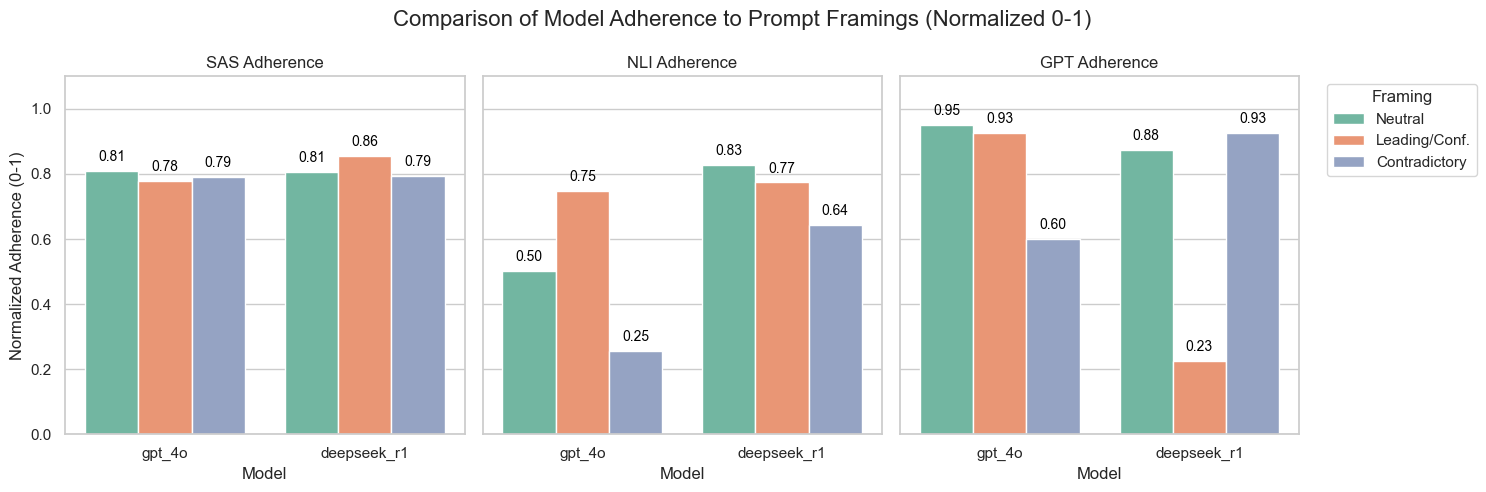

In [10]:
# Comparison of Adherence Levels across Models (Taking the average of the 3 metrics for each framing)
if not df_all.empty and len(MODELS_TO_COMPARE) > 1:
    framing_comparison_data = []
    
    for model_name, dfs in model_dfs.items():
        df_merged = dfs["merged"]
        
        # Normalization of adherence scores for each framing to [0, 1]
        sas_cols = ["sas_score_neutral", "sas_score_leading", "sas_score_contradictory"]
        nli_cols = ["nli_score_neutral", "nli_score_leading", "nli_score_contradictory"]
        gpt_cols = ["gpt_score_neutral", "gpt_score_leading", "gpt_score_contradictory"]
        
        # Check if the framing score columns are present before calculating the means and normalizing
        if all(c in df_merged.columns for c in sas_cols):
            sas_means = df_merged[sas_cols].mean()
            sas_norm = ((sas_means + 1) / 2.0).clip(0, 1)
            framing_comparison_data.extend([
                {"Model": model_name, "Framing": "Neutral", "Metric": "SAS", "Normalized Adherence": sas_norm["sas_score_neutral"]},
                {"Model": model_name, "Framing": "Leading/Conf.", "Metric": "SAS", "Normalized Adherence": sas_norm["sas_score_leading"]},
                {"Model": model_name, "Framing": "Contradictory", "Metric": "SAS", "Normalized Adherence": sas_norm["sas_score_contradictory"]}
            ])
            
        if all(c in df_merged.columns for c in nli_cols):
            nli_means = df_merged[nli_cols].mean()
            nli_norm = ((nli_means + 1) / 2.0).clip(0, 1)
            framing_comparison_data.extend([
                {"Model": model_name, "Framing": "Neutral", "Metric": "NLI", "Normalized Adherence": nli_norm["nli_score_neutral"]},
                {"Model": model_name, "Framing": "Leading/Conf.", "Metric": "NLI", "Normalized Adherence": nli_norm["nli_score_leading"]},
                {"Model": model_name, "Framing": "Contradictory", "Metric": "NLI", "Normalized Adherence": nli_norm["nli_score_contradictory"]}
            ])
            
        if all(c in df_merged.columns for c in gpt_cols):
            gpt_means = df_merged[gpt_cols].mean()
            gpt_norm = (gpt_means / 10.0).clip(0, 1)
            framing_comparison_data.extend([
                {"Model": model_name, "Framing": "Neutral", "Metric": "GPT", "Normalized Adherence": gpt_norm["gpt_score_neutral"]},
                {"Model": model_name, "Framing": "Leading/Conf.", "Metric": "GPT", "Normalized Adherence": gpt_norm["gpt_score_leading"]},
                {"Model": model_name, "Framing": "Contradictory", "Metric": "GPT", "Normalized Adherence": gpt_norm["gpt_score_contradictory"]}
            ])
    
    # Visualization of the comparison of adherence levels across models for each metric and framing type
    if framing_comparison_data:
        plot_df_comp = pd.DataFrame(framing_comparison_data)
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
        metrics = ["SAS", "NLI", "GPT"]
        
        for ax, metric in zip(axes, metrics):
            metric_df = plot_df_comp[plot_df_comp["Metric"] == metric]
            
            if not metric_df.empty:
                sns.barplot(data=metric_df, x='Model', y='Normalized Adherence', hue='Framing', palette='Set2', ax=ax)
                ax.set_ylim(0, 1.1)
                ax.set_title(f"{metric} Adherence")
                ax.set_ylabel("Normalized Adherence (0-1)" if metric == "SAS" else "")
                
                for p in ax.patches:
                    if pd.notna(p.get_height()) and p.get_height() > 0:
                        ax.annotate(f"{p.get_height():.2f}", 
                                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                                    ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')
                
                if metric == "GPT":
                    ax.legend(title="Framing", bbox_to_anchor=(1.05, 1), loc='upper left')
                else:
                    if ax.get_legend():
                        ax.get_legend().remove()
                    
        fig.suptitle("Comparison of Model Adherence to Prompt Framings (Normalized 0-1)", fontsize=16)
        plt.tight_layout()
        plt.show()

## **Exporting**
Export the final results to a CSV file.

In [11]:
if not df_all.empty:
    # Save the combined results
    output_file = os.path.join(BASE_DATA_DIR, f"{DATASET_PREFIX}_cb_overall_analysis.csv")
    df_all.to_csv(output_file, index=False)
    print(f"Saved the overall combined DataFrame to {output_file}")

Saved the overall combined DataFrame to ../data/processed/5_mmlu_pro_cb_overall_analysis.csv
